## What this notebook does

1. Creates a single simulated WAV file containing pink noise.
2. Runs PyPAM on that file to compute hybrid millidecade bands.
3. Runs NoiseApp on the same file with the corrected erratum transition.
4. Plots the two mean spectra and reports the frequency-by-frequency difference.

The calibration is kept simple on purpose. Both tools use a flat scalar sensitivity of `0 dB re 1 V/µPa`, and PyPAM uses `Vpp=2.0` so the WAV samples map directly onto the same amplitude convention used by NoiseApp.

# PyPAM vs YAWN Validation with Simulated Pink Noise

This notebook is a self-contained version of `PypamValidation.py`. It generates a synthetic pink-noise WAV file, runs the same hybrid millidecade analysis in PyPAM and NoiseApp, and plots the two mean spectra on top of each other.

Pink noise is useful here because its 1/f spectrum exercises both low and high frequencies in a way that makes calibration differences easy to see.

## Imports

The notebook uses the scientific Python stack, `noiseProcessGoogleCloud` for YAWN/NoiseApp, and `pypam` plus `pyhydrophone` for the comparison run.

In [6]:
# Run this notebook in the pypam conda environment:
#   conda activate pypam
#   jupyter notebook

import warnings
from pathlib import Path
import tempfile
import os

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import pyhydrophone as pyhy
import pypam

from noiseProcessGoogleCloud import NoiseApp

warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", category=FutureWarning, module="google.api_core")
mpl.rcParams["text.usetex"] = False
plt.rcParams["text.usetex"] = False


## Helper functions

The first helper creates a pink-noise WAV file. The second helper loads the HDF5 output from NoiseApp and extracts the mean hybrid millidecade spectrum for plotting.

In [7]:
def simulate_pink_noise_wav(out_wav: Path, fs: int = 48000, duration_s: float = 120.0, seed: int = 7):
    rng = np.random.default_rng(seed)
    n = int(fs * duration_s)

    white = rng.standard_normal(n)
    spectrum = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)

    shaping = np.ones_like(freqs)
    if len(shaping) > 1:
        shaping[0] = 0.0
        shaping[1:] = np.sqrt(1.0 / np.maximum(freqs[1:], 1.0))

    pink = np.fft.irfft(spectrum * shaping, n=n)
    pink = pink - np.mean(pink)
    peak = float(np.max(np.abs(pink)))
    if peak > 0:
        pink = 0.9 * pink / peak

    sf.write(out_wav, pink.astype(np.float32), fs)
    return pink.astype(np.float32), fs


def extract_noiseapp_mean_hybrid(h5_path: Path, dep_name: str):
    with h5py.File(h5_path, 'r') as h5:
        group = h5[dep_name]
        hybrid = np.asarray(group['hybridMiliDecLevels'][:], dtype=float)
        freq_lims = np.asarray(group['hybridDecFreqHz'][:], dtype=float)

    flo = freq_lims[:, 0]
    freq = freq_lims[:, 1]
    fhi = freq_lims[:, 2]
    bw = fhi - flo

    mean_db = 10.0 * np.log10(np.nanmean(np.power(10.0, hybrid / 10.0), axis=0))
    return freq, mean_db, flo, fhi, bw

## Simulate the pink-noise file

The WAV filename uses a timestamp format that both tools can parse. The output directory is placed in the system temp folder so the notebook stays self-contained.

In [8]:
output_root = Path(tempfile.gettempdir()) / 'PypamValidation_PinkNoise'
output_root.mkdir(parents=True, exist_ok=True)

sim_dir = output_root / 'sim_audio'
sim_dir.mkdir(exist_ok=True)
wav_path = sim_dir / '20260511_120000.wav'

_, fs_local = simulate_pink_noise_wav(wav_path, fs=48000, duration_s=120.0, seed=7)

print('Output root:', output_root)
print('Simulated WAV:', wav_path)
print('Sample rate:', fs_local)

Output root: C:\Users\kaity\AppData\Local\Temp\PypamValidation_PinkNoise
Simulated WAV: C:\Users\kaity\AppData\Local\Temp\PypamValidation_PinkNoise\sim_audio\20260511_120000.wav
Sample rate: 48000


## Run PyPAM and NoiseApp

Both analyses use the same file, the same averaging window, and the same flat calibration. The only goal here is to compare the hybrid millidecade output.

In [9]:
band = [0, fs_local / 2.0]
nfft = fs_local
binsize = 30.0

hydrophone = pyhy.hydrophone.Hydrophone(
    name='PINK_NOISE_TEST',
    model='GENERIC',
    serial_number=1,
    sensitivity=0.0,
    preamp_gain=0.0,
    Vpp=2.0,
    string_format='%Y%m%d_%H%M%S',
    calibration_file=None,
)

asa = pypam.ASA(
    hydrophone=hydrophone,
    folder_path=str(sim_dir),
    binsize=binsize,
    nfft=nfft,
    fft_overlap=0.5,
    timezone='UTC',
    include_dirs=False,
    zipped=False,
    dc_subtract=True,
    channel=0,
    calibration=None,
)

pam_ds = asa.hybrid_millidecade_bands(db=True, method='density', band=band, percentiles=None)
pam_da = pam_ds['millidecade_bands']
freq_pam = np.asarray(pam_da.coords['frequency_bins'].values, dtype=float)
spec_pam = 10.0 * np.log10(np.nanmean(np.power(10.0, np.asarray(pam_da.values, dtype=float) / 10.0), axis=0))

out_dir = output_root / 'noiseapp_output'
out_dir.mkdir(exist_ok=True)

app = NoiseApp(
    soundFilePath=str(sim_dir),
    ProjName='PINK_NOISE_TEST',
    DepName='PINK_NOISE_DEPLOYMENT',
    DatabaseLoc=str(out_dir),
    Si=0.0,
    Si_units='V/uPa',
    aveSec=binsize,
    r=0.5,
    rmDC=True,
    split_hdf5_by_day=False,
    existing_deployment_mode='overwrite',
)
app.run_analysis()

freq_app, spec_app, flo_app, fhi_app, bw_app = extract_noiseapp_mean_hybrid(Path(app.fullPath), app.DepName)

print('PyPAM dataset shape:', pam_da.shape)
print('NoiseApp HDF5:', app.fullPath)

  0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\kaity\AppData\Local\Temp\PypamValidation_PinkNoise\sim_audio\20260511_120000.wav
Filename 20260511_120000.wav does not match the PINK_NOISE_TEST file structure. Setting time to now...


100%|██████████| 1/1 [00:00<00:00,  1.52it/s]


Preparing HDF5 File PINK_NOISE_TEST.h5
Writing to HDF5: PINK_NOISE_TEST.h5
20260511_120000.wav
PyPAM dataset shape: (4, 2178)
NoiseApp HDF5: C:\Users\kaity\AppData\Local\Temp\PypamValidation_PinkNoise\noiseapp_output\PINK_NOISE_TEST.h5


## Plot the comparison

The top panel overlays the hybrid millidecade mean spectra from PyPAM and YAWN. The bottom panel shows the frequency-by-frequency difference after interpolating YAWN onto the PyPAM frequency grid.

Median offset (YAWN - PyPAM): -4.767452600873412e-05 dB
5th-95th percentile of offset: [-0.00686042  0.00678891] dB


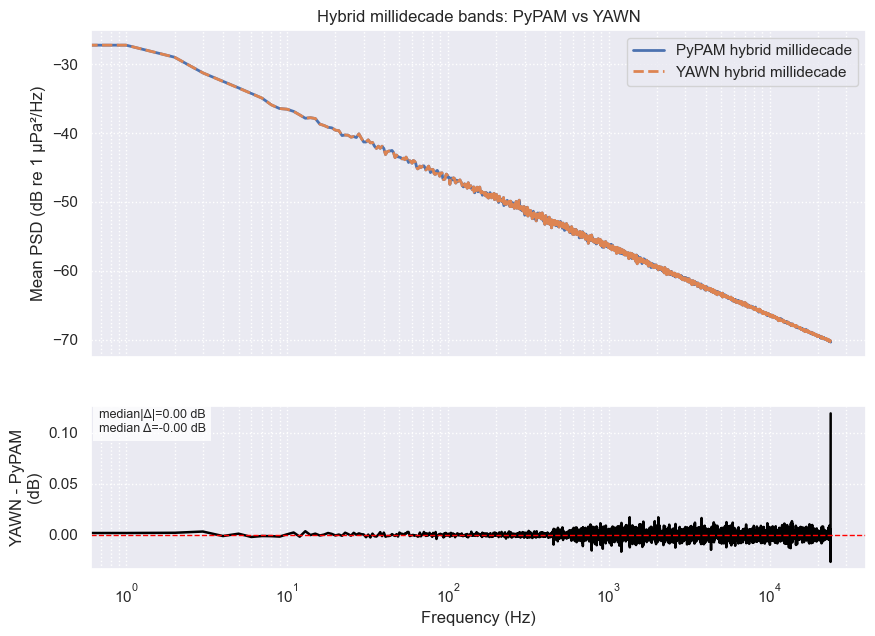

In [10]:
spec_app_interp = np.interp(freq_pam, freq_app, spec_app)
delta = spec_app_interp - spec_pam

print('Median offset (YAWN - PyPAM):', float(np.nanmedian(delta)), 'dB')
print('5th-95th percentile of offset:', np.nanpercentile(delta, [5, 95]), 'dB')

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={'height_ratios': [2.0, 1.0]})
ax_top.semilogx(freq_pam, spec_pam, label='PyPAM hybrid millidecade', linewidth=2)
ax_top.semilogx(freq_app, spec_app, label='YAWN hybrid millidecade', linewidth=2, linestyle='--')
ax_top.set_title('Hybrid millidecade bands: PyPAM vs YAWN')
ax_top.set_ylabel('Mean PSD (dB re 1 µPa²/Hz)')
ax_top.grid(True, which='both', linestyle=':')
ax_top.legend(loc='best')

ax_bottom.semilogx(freq_pam, delta, color='black', linewidth=1.8)
ax_bottom.axhline(0.0, color='red', linestyle='--', linewidth=1)
ax_bottom.set_xlabel('Frequency (Hz)')
ax_bottom.set_ylabel('YAWN - PyPAM\n(dB)')
ax_bottom.grid(True, which='both', linestyle=':')
ax_bottom.text(
    0.01,
    0.98,
    f'median|Δ|={np.nanmedian(np.abs(delta)):.2f} dB\nmedian Δ={np.nanmedian(delta):.2f} dB',
    transform=ax_bottom.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)

# layout left to default to avoid LaTeX-dependent size measurement
plt.show()

## Notes: code-level cause of the remaining differences

The residual differences above the 1 Hz transition are now traced to specific implementation details in source code (not just theory):

1. **NoiseApp quantizes hybrid levels to 0.01 dB before writing**
   - In `noiseProcessGoogleCloud.py`, `calcHybridMilidecades(...)` returns `np.round(out, 2)`.
   - In the analysis loop, NoiseApp rounds again before saving: `milidec = np.round(self.calcHybridMilidecades(apsd_60), 2)`.
   - PyPAM does **not** round hybrid bands to 0.01 dB in its banding path, so this quantization alone creates a small floor of mismatch (typically millidecibel-scale after averaging).

2. **Band-edge accumulation is implemented differently**
   - NoiseApp (`calcHybridMilidecades`) computes overlap directly from FFT-bin edges (`bin_lo/bin_hi`) and integrates with overlap-in-Hz weights.
   - PyPAM (`utils.spectra_ds_to_bands`) uses index-based band limits plus explicit `lower_factor`/`upper_factor` fractional-bin terms at boundaries.
   - Both are valid partial-bin integrations, but they are not numerically identical at band edges, especially right after the 435 Hz transition where bandwidth is just above 1 Hz.

3. **The plotted delta includes interpolation onto one grid**
   - The comparison computes `spec_app_interp = np.interp(freq_pam, freq_app, spec_app)` and then `delta = spec_app_interp - spec_pam`.
   - That interpolation step adds an additional tiny residual when centers are not perfectly coincident.

What this means for this notebook:

- Differences above the cutoff are small and mostly due to the 0.01 dB NoiseApp quantization plus boundary-integration implementation differences.
- Large, structured offsets are still a sign of a true configuration mismatch (timestamp parsing, `Vpp`, `Si`, or stale output not overwritten).